# Növénybetegségek felismerése neurális hálóval

Cuda 13.0

In [ ]:
%pip install kagglehub
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
%pip install matplotlib

In [1]:
import shutil
import kagglehub
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt

d:\03_Projects\Advanced-Machine-Learning\aml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Az adathalmaz
Kaggle: [PlantVillage](https://www.kaggle.com/datasets/mohitsingh1804/plantvillage)

In [ ]:
shutil.rmtree("./data/")

local_path = "./data"
path = kagglehub.dataset_download("mohitsingh1804/plantvillage")

shutil.move(path, local_path)

print("Dataset downloaded and moved to:", local_path)

Batch méret és kép méret (ResNet miatt)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

BATCH_SIZE = 32
IMG_SIZE = 224

train_dir = "data/PlantVillage/train"
val_dir = "data/PlantVillage/val"

Device: cuda


In [3]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet
        std=[0.229, 0.224, 0.225]
    )
])

Eredeti *val* halmaz -> *test* halmaz

*train* 20% -> új *val* halmaz

In [4]:
full_train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

test_dataset = datasets.ImageFolder(root=val_dir, transform=transform)

In [5]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
class_names = full_train_dataset.classes
num_classes = len(class_names)

print("Osztályok száma:", num_classes)

Osztályok száma: 38


In [7]:
images, labels = next(iter(train_loader))

print("Képek shape:", images.shape)   # [batch, 3, 224, 224]
print("Címkék shape:", labels.shape)

Képek shape: torch.Size([32, 3, 224, 224])
Címkék shape: torch.Size([32])


In [8]:
model = models.resnet18(pretrained=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, num_classes)

model = model.to(device)

d:\03_Projects\Advanced-Machine-Learning\aml\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\03_Projects\Advanced-Machine-Learning\aml\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
def train_model(model, train_loader, val_loader, epochs=5, save_path="best_model.pth"):
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    best_acc = 0.0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        print("-" * 40)

        # ===== TRAIN =====
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc="Training", leave=False)

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loop.set_postfix({
                "loss": loss.item(),
                "acc": correct / total
            })

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        train_losses.append(train_loss)

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validation", leave=False):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = correct / total

        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        # ===== MODELL MENTÉS =====
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print(f"Új legjobb modell mentve! (Val Acc: {val_acc:.4f})")

        # ===== EPOCH SUMMARY =====
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    print(f"\nLegjobb validációs accuracy: {best_acc:.4f}")
    print(f"Modell mentve ide: {save_path}")

    return train_losses, val_losses, val_accuracies

In [14]:
train_losses, val_losses, val_accuracies = train_model(
    model,
    train_loader,
    val_loader,
    epochs=2,
    save_path="best_model.pth"
)


Epoch 1/2
----------------------------------------


Új legjobb modell mentve! (Val Acc: 0.9698)
Train Loss: 0.1357 | Train Acc: 0.9567
Val   Loss: 0.0970 | Val   Acc: 0.9698

Epoch 2/2
----------------------------------------


Train Loss: 0.0989 | Train Acc: 0.9689
Val   Loss: 0.1130 | Val   Acc: 0.9641

Legjobb validációs accuracy: 0.9698
Modell mentve ide: best_model.pth


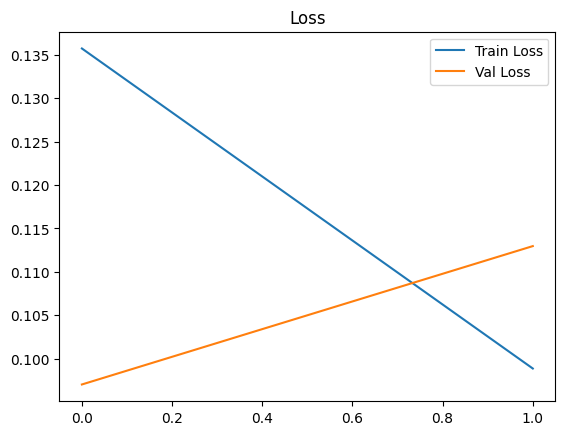

In [16]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")
plt.show()

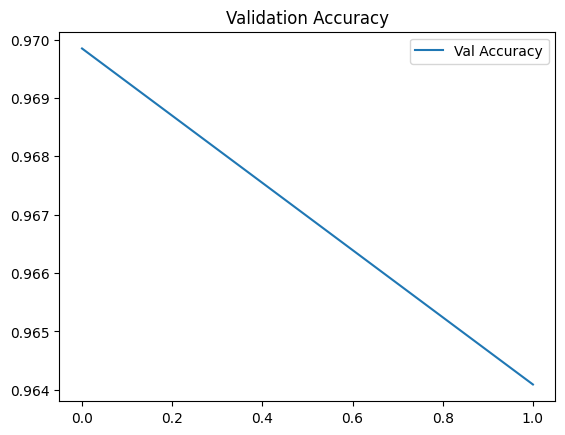

In [17]:
plt.plot(val_accuracies, label="Val Accuracy")
plt.legend()
plt.title("Validation Accuracy")
plt.show()

In [ ]:
def evaluate_test(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    loop = tqdm(test_loader, desc="Testing")

    with torch.no_grad():
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            loop.set_postfix({
                "acc": correct / total
            })

    accuracy = correct / total
    print("\nTest Accuracy:", accuracy)

    return all_preds, all_labels

In [22]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

preds, labels = evaluate_test(model, test_loader)

Testing: 100%|██████████| 340/340 [01:38<00:00,  3.44it/s, acc=0.968]


Test Accuracy: 0.9682349691556947
